# Step 3: Melt rate against ocean temperature

How does the area-mean melt rate change when the ocean far from the grounding line is warmer? I hold the far field at -1.9, -1.4, -0.9 and +0.1 °C (the baseline plus 0.5, 1 and 2 °C), run each case until the melt rate settles, and compare the melt rate with the thermal forcing (how far above freezing the far-field water is).

The default `isomip` box is sealed, fully covered by ice, and has no source of heat (step 2), so the far field has to be held warm. My first design restored temperature and salinity under the ice and failed in an instructive way (Part B1). The final design removes the ice in the northernmost 1° to make an open-ocean restoring zone, like ISOMIP+ (Part A and Part B2).

I load the libraries and shared functions, and set the cases, the restoring zone and the paths.

In [1]:
%matplotlib inline

import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from MITgcmutils import rdmds

sys.path.append("../src")   # isomip_tools.py lives in the project's src/ folder
from isomip_tools import (read_grid, output_iterations, read_field, melt_rate, area_mean, melt_series,
                          freezing_point, pressure_dbar, NX, NY, NR)

RUNS = os.path.expanduser("~/mitgcm_runs/isomip")
INPUT = os.path.join(RUNS, "source_copy", "input")
FIELD_DIR = os.path.join(RUNS, "inputs_rbcs")         # 3D input fields (1.2 MB each), outside the repo
GEOMETRY_DIR = "../experiments/open_geometry"          # 2D geometry files (40 kB each), in the repo
T_FAR = {"base": -1.9, "p05": -1.4, "p10": -0.9, "p20": 0.1}   # far-field (restoring) temperature of each case (°C)
S_FAR = 34.4                     # far-field salinity (g/kg)
ZONE_SOUTH = -71.0               # ice front: ice removed and restoring applied north of this latitude
ZONE_NORTH = -70.0               # northern wall
REFERENCE_DEPTH = 693.75         # depth of the deepest ice base (m): thermal forcing is measured here
STEADY_LIMIT = 2.0               # "steady" = melt changes by less than 2% per year over the last two years
FIG_DIR = "../figures"
DATA_DIR = "../data"
os.makedirs(FIELD_DIR, exist_ok=True)
os.makedirs(GEOMETRY_DIR, exist_ok=True)
colors = {"base": "tab:blue", "p05": "tab:green", "p10": "tab:orange", "p20": "tab:red"}

## Part A: the open-ocean restoring zone

I read the grid from the step 2 baseline run and the original geometry files. The ice load (`phi0surf`) depends only on the ice draft, because the starting water is uniform: cells with the same draft have exactly the same load. So where I remove the ice, the right load is zero.

In [2]:
grid = read_grid(os.path.join(RUNS, "baseline"), INPUT)
lat = grid["yc"][:, 0]
ocean = grid["depth"] > 0
ice = np.fromfile(os.path.join(INPUT, "icetopo.exp1"), dtype=">f8").reshape(NY, NX)
load = np.fromfile(os.path.join(INPUT, "phi0surf.exp1.jmd95z"), dtype=">f8").reshape(NY, NX)
spread = 0.0
for draft in np.unique(ice[ocean]):
    same = ocean & (ice == draft)
    spread = max(spread, load[same].max() - load[same].min())
print(f"largest difference in load between ocean cells with the same draft: {spread}")

largest difference in load between ocean cells with the same draft: 0.0


I remove the ice north of 71°S (rows 90-99): ice draft 0 m and load 0. The ice shelf now ends in a 200 m high ice front at 71°S, with open ocean to the north. The files keep the original format (64-bit, big-endian, 100 x 50).

In [3]:
open_zone = np.zeros((NY, NX), dtype=bool)
for j in range(NY):
    if lat[j] > ZONE_SOUTH:
        open_zone[j, :] = True
ice_open = ice.copy()
load_open = load.copy()
ice_open[open_zone] = 0.0
load_open[open_zone] = 0.0
ice_open.astype(">f8").tofile(os.path.join(GEOMETRY_DIR, "icetopo_open_north.bin"))
load_open.astype(">f8").tofile(os.path.join(GEOMETRY_DIR, "phi0surf_open_north.bin"))
rows = np.where(open_zone[:, 0])[0]
print(f"ice removed in rows {rows[0]}-{rows[-1]} (latitude {lat[rows[0]]:.2f} to {lat[rows[-1]]:.2f}); "
      f"ice still covers {np.sum(ocean & (ice_open < 0))} of {np.sum(ocean)} ocean columns")
for name in ["icetopo_open_north.bin", "phi0surf_open_north.bin"]:
    print(name, os.path.getsize(os.path.join(GEOMETRY_DIR, name)), "bytes")

ice removed in rows 90-99 (latitude -70.95 to -70.05); ice still covers 4361 of 4851 ocean columns
icetopo_open_north.bin 40000 bytes
phi0surf_open_north.bin 40000 bytes


The restoring mask is 0 at the ice front (71°S) and rises linearly to the northern wall, at every depth, only in the open-ocean zone. The temperature and salinity targets are uniform. These fields are 3D (30 x 100 x 50, 64-bit) and are written outside the repo.

In [4]:
mask = np.zeros((NR, NY, NX))
for j in range(NY):
    if open_zone[j, 0]:
        strength = (lat[j] - ZONE_SOUTH) / (ZONE_NORTH - ZONE_SOUTH)
        for i in range(NX):
            if ocean[j, i]:
                mask[:, j, i] = strength
print(f"mask from {mask[mask > 0].min():.2f} to {mask.max():.2f} in {np.sum(mask > 0)} cells")

def write_field(name, field):
    field.astype(">f8").tofile(os.path.join(FIELD_DIR, name))
    print(f"wrote {name}: {os.path.getsize(os.path.join(FIELD_DIR, name))} bytes")

write_field("rbcs_mask_open.bin", mask)
write_field("salt_34p4.bin", np.full((NR, NY, NX), S_FAR))

# The first design (part B1) used a mask on the old geometry: the same ramp, but only in cells that were
# water under the ice (hFacC > 0 in the baseline grid). I rebuild it under its own name so those runs
# can still be reproduced.
mask_first = np.zeros((NR, NY, NX))
for j in range(NY):
    if lat[j] > ZONE_SOUTH:
        mask_first[:, j, :] = np.where(grid["hfacc"][:, j, :] > 0, (lat[j] - ZONE_SOUTH) / (ZONE_NORTH - ZONE_SOUTH), 0.0)
write_field("rbcs_mask.bin", mask_first)
for case, t_far in T_FAR.items():
    write_field(f"theta_rbcs_{case}.bin", np.full((NR, NY, NX), t_far))

mask from 0.05 to 0.95 in 14700 cells
wrote rbcs_mask_open.bin: 1200000 bytes
wrote salt_34p4.bin: 1200000 bytes
wrote rbcs_mask.bin: 1200000 bytes
wrote theta_rbcs_base.bin: 1200000 bytes
wrote theta_rbcs_p05.bin: 1200000 bytes
wrote theta_rbcs_p10.bin: 1200000 bytes
wrote theta_rbcs_p20.bin: 1200000 bytes


This section shows the new geometry and the restoring mask along the cavity.

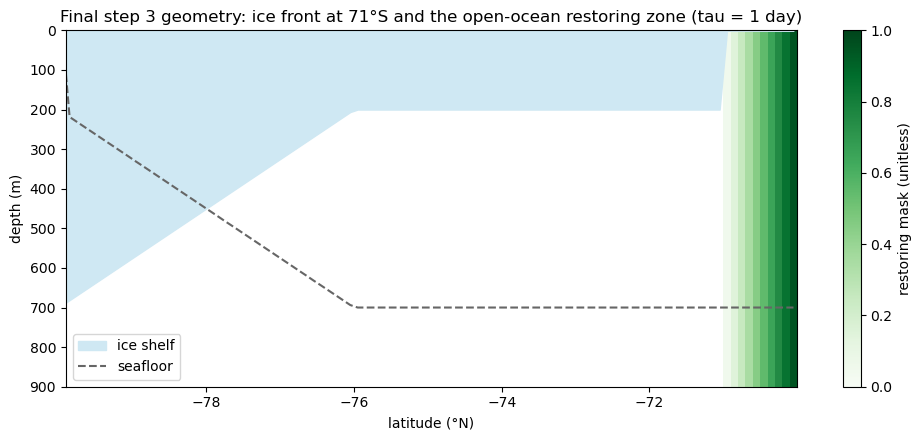

In [5]:
lat_edges = np.concatenate([lat - 0.05, [lat[-1] + 0.05]])
depth_faces = np.concatenate([[0.0], np.cumsum(grid["drf"])])
column = 25
fig, ax = plt.subplots(figsize=(10, 4.5))
section = np.where(mask[:, :, column] > 0, mask[:, :, column], np.nan)
mesh = ax.pcolormesh(lat_edges, depth_faces, section, cmap="Greens", vmin=0, vmax=1)
ax.fill_between(lat, 0, -ice_open[:, column], color="#cfe8f3", label="ice shelf")
ax.plot(lat, grid["depth"][:, column], color="0.4", ls="--", label="seafloor")
ax.set_ylim(900, 0)
ax.set_xlim(lat_edges[1], lat_edges[-1])
ax.set_xlabel("latitude (°N)")
ax.set_ylabel("depth (m)")
ax.set_title("Final step 3 geometry: ice front at 71°S and the open-ocean restoring zone (tau = 1 day)")
fig.colorbar(mesh, ax=ax, label="restoring mask (unitless)")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_open_geometry_mask.png"), dpi=150)
plt.show()

The thermal forcing of each case: the far-field temperature minus the freezing point of 34.4 g/kg water at the depth of the deepest ice base (693.75 m), with the three-equation model's freezing formula.

In [6]:
t_freeze_ref = freezing_point(S_FAR, pressure_dbar(REFERENCE_DEPTH))
thermal_forcing = {case: t - t_freeze_ref for case, t in T_FAR.items()}
print(f"freezing point at {REFERENCE_DEPTH} m ({pressure_dbar(REFERENCE_DEPTH):.1f} dbar), S = {S_FAR}: {t_freeze_ref:.3f} °C")
for case in T_FAR:
    print(f"{case:5s}: far field {T_FAR[case]:+.1f} °C, thermal forcing {thermal_forcing[case]:.3f} °C")

freezing point at 693.75 m (701.0 dbar), S = 34.4: -2.421 °C
base : far field -1.9 °C, thermal forcing 0.521 °C
p05  : far field -1.4 °C, thermal forcing 1.021 °C
p10  : far field -0.9 °C, thermal forcing 1.521 °C
p20  : far field +0.1 °C, thermal forcing 2.521 °C


## Part B1: what went wrong with the first design

My first design kept the ice everywhere and restored temperature and salinity over 10 days in the northernmost 1°, under the flat 200 m ice. Each case started uniformly warm (`experiments/rbcs_*`). I keep these runs only as a lesson. Here I split their last-year melt into the restoring zone and the rest.

In [7]:
zone_cols = grid["wet"] & (grid["yc"] > ZONE_SOUTH)
rest_cols = grid["wet"] & ~zone_cols
for case in T_FAR:
    run = os.path.join(RUNS, f"rbcs_{case}")
    its = output_iterations(run, "shelfice_monthly")[-12:]
    m = np.zeros(grid["wet"].shape)
    for it in its:
        m += melt_rate(read_field(run, "shelfice_monthly", "SHIfwFlx", it)) / len(its)
    print(f"rbcs_{case:4s}: melt in the restoring zone {area_mean(m, grid, zone_cols):6.3f} m/yr | "
          f"outside it {area_mean(m, grid, rest_cols):.4f} m/yr")
base_old = np.zeros(grid["wet"].shape)
sealed = np.zeros(grid["wet"].shape)
for it in output_iterations(os.path.join(RUNS, "rbcs_base"), "shelfice_monthly")[-12:]:
    base_old += melt_rate(read_field(os.path.join(RUNS, "rbcs_base"), "shelfice_monthly", "SHIfwFlx", it))
    sealed += melt_rate(read_field(os.path.join(RUNS, "baseline"), "shelfice_monthly", "SHIfwFlx", it))
same = grid["wet"] & (np.abs(base_old - sealed) / 12 < 1e-6)
print(f"cells where rbcs_base and the sealed step-2 baseline agree within 1e-6 m/yr: {same.sum()} of {grid['wet'].sum()}, "
      f"all south of {lat[np.where(same.any(axis=1))[0].max()]:.2f}°N")

rbcs_base: melt in the restoring zone  0.550 m/yr | outside it 0.0478 m/yr
rbcs_p05 : melt in the restoring zone  2.587 m/yr | outside it 0.2704 m/yr
rbcs_p10 : melt in the restoring zone  4.758 m/yr | outside it 0.5531 m/yr
rbcs_p20 : melt in the restoring zone  9.524 m/yr | outside it 1.2336 m/yr
cells where rbcs_base and the sealed step-2 baseline agree within 1e-6 m/yr: 1189 of 4851, all south of -74.55°N


## Part B2: the final design

Four runs (`experiments/open_*`), each 10 model years from the original cold start (-1.9 °C, 34.4 g/kg, at rest), differing only in the restoring target. I read the grid with the new ice draft, and average the melt over ice-covered columns only.

In [8]:
def case_runs(case):
    # open_<case>, followed by open_<case>_ext if I continued that run (see the steadiness test below)
    runs = [os.path.join(RUNS, f"open_{case}")]
    ext = os.path.join(RUNS, f"open_{case}_ext")
    if os.path.exists(os.path.join(ext, "output.txt")):
        runs.append(ext)
    return runs

grid_open = read_grid(os.path.join(RUNS, "open_base"), GEOMETRY_DIR, ice_file="icetopo_open_north.bin")
iced = grid_open["iced"]
zone3d = (mask > 0.5) & (grid_open["hfacc"] > 0)
print(f"ice-covered columns: {iced.sum()} | open-ocean columns: {np.sum(grid_open['wet'] & ~iced)}")
for case in T_FAR:
    for run in case_runs(case):
        text = open(os.path.join(run, "output.txt")).read()
        bad = 0
        its = output_iterations(run, "shelfice_monthly")
        for it in its:
            if not np.all(np.isfinite(rdmds(os.path.join(run, "shelfice_monthly"), it))):
                bad += 1
        last = output_iterations(run, "state_yearly")[-1]
        theta = read_field(run, "state_yearly", "THETA", last)
        open_melt = melt_rate(read_field(run, "shelfice_monthly", "SHIfwFlx", its[-1]))[grid_open["wet"] & ~iced]
        print(f"{os.path.basename(run):13s} ended normally: {'Execution ended Normally' in text} | NaN in log: {'NaN' in text} | "
              f"{len(its)} monthly means ({bad} non-finite) | zone temperature (mask > 0.5) {theta[zone3d].mean():+.3f} °C "
              f"(target {T_FAR[case]:+.1f}) | largest |melt| in the open zone {np.abs(open_melt).max():.1e} m/yr")

ice-covered columns: 4361 | open-ocean columns: 490
open_base     ended normally: True | NaN in log: False | 121 monthly means (0 non-finite) | zone temperature (mask > 0.5) -1.900 °C (target -1.9) | largest |melt| in the open zone 0.0e+00 m/yr


open_base_ext ended normally: True | NaN in log: False | 122 monthly means (0 non-finite) | zone temperature (mask > 0.5) -1.900 °C (target -1.9) | largest |melt| in the open zone 0.0e+00 m/yr


open_p05      ended normally: True | NaN in log: False | 121 monthly means (0 non-finite) | zone temperature (mask > 0.5) -1.400 °C (target -1.4) | largest |melt| in the open zone 0.0e+00 m/yr
open_p05_ext  ended normally: True | NaN in log: False | 122 monthly means (0 non-finite) | zone temperature (mask > 0.5) -1.400 °C (target -1.4) | largest |melt| in the open zone 0.0e+00 m/yr


open_p10      ended normally: True | NaN in log: False | 121 monthly means (0 non-finite) | zone temperature (mask > 0.5) -0.900 °C (target -0.9) | largest |melt| in the open zone 0.0e+00 m/yr


open_p20      ended normally: True | NaN in log: False | 121 monthly means (0 non-finite) | zone temperature (mask > 0.5) +0.100 °C (target +0.1) | largest |melt| in the open zone 0.0e+00 m/yr


Area-mean melt over the ice for every 30-day mean, and the steadiness test: the change between the last two 12-month means, in percent per year. After the first 10 years, `open_base` and `open_p05` were still drifting by more than 2% per year, so I continued them for 10 more years from their year-10 pickup files (`experiments/open_base_ext`, `experiments/open_p05_ext`). For these two cases the series joins both parts.

open_base (20 years): first month 0.9650 | year 1 0.2323 | last 12 months 0.0252 m/yr | 12 months before 0.0262 | change -3.68% per year -> NOT steady


open_p05  (20 years): first month 0.9796 | year 1 0.2845 | last 12 months 0.1039 m/yr | 12 months before 0.1037 | change +0.20% per year -> steady
open_p10  (10 years): first month 0.9936 | year 1 0.3472 | last 12 months 0.2074 m/yr | 12 months before 0.2116 | change -1.98% per year -> steady


open_p20  (10 years): first month 1.0297 | year 1 0.5123 | last 12 months 0.4149 m/yr | 12 months before 0.4136 | change +0.31% per year -> steady


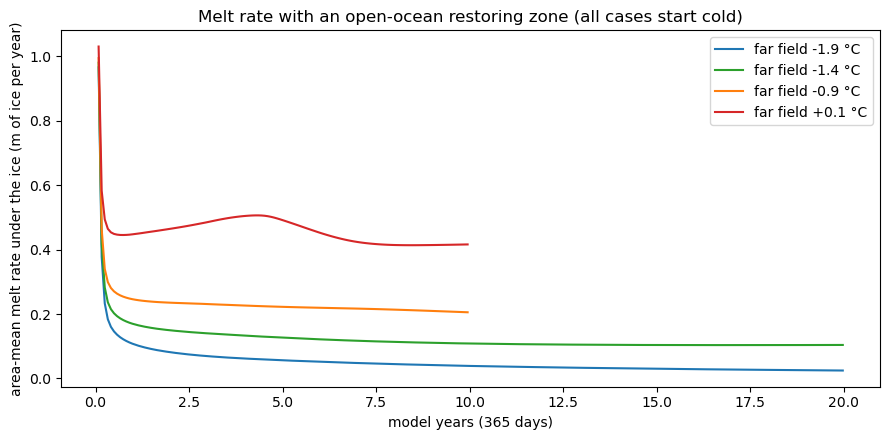

In [9]:
series = {}
change = {}
for case in T_FAR:
    days, melt = melt_series(case_runs(case), grid_open, iced)
    series[case] = (days, melt)
    last = melt[-12:].mean()
    before = melt[-24:-12].mean()
    change[case] = 100 * (last - before) / before
    status = "steady" if abs(change[case]) < STEADY_LIMIT else "NOT steady"
    print(f"open_{case:4s} ({days[-1] / 365:.0f} years): first month {melt[0]:.4f} | year 1 {melt[:12].mean():.4f} | last 12 months {last:.4f} m/yr | "
          f"12 months before {before:.4f} | change {change[case]:+.2f}% per year -> {status}")

fig, ax = plt.subplots(figsize=(9, 4.5))
for case, (days, melt) in series.items():
    ax.plot(days / 365.0, melt, color=colors[case], label=f"far field {T_FAR[case]:+.1f} °C")
ax.set_xlabel("model years (365 days)")
ax.set_ylabel("area-mean melt rate under the ice (m of ice per year)")
ax.set_title("Melt rate with an open-ocean restoring zone (all cases start cold)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_melt_timeseries.png"), dpi=150)
plt.show()

The steady melt rate of each case is the mean of its last 12 months. I also compute the actual thermal forcing from the zone's real temperature, and the thermal driving the model sees in the top wet cell under the ice.

In [10]:
steady = {}
tf_actual = {}
local_driving = {}
for case in T_FAR:
    run = case_runs(case)[-1]
    steady[case] = series[case][1][-12:].mean()
    last = output_iterations(run, "state_yearly")[-1]
    theta = read_field(run, "state_yearly", "THETA", last)
    salt = read_field(run, "state_yearly", "SALT", last)
    tf_actual[case] = theta[zone3d].mean() - t_freeze_ref
    top = np.zeros((NY, NX))
    for j in range(NY):
        for i in range(NX):
            k = grid_open["ktop"][j, i]
            if iced[j, i] and k >= 0:
                top[j, i] = theta[k, j, i] - freezing_point(salt[k, j, i], pressure_dbar(-grid_open["rc"][k]))
    local_driving[case] = area_mean(top, grid_open, iced)
    print(f"open_{case:4s}: thermal forcing {thermal_forcing[case]:.3f} °C (actual {tf_actual[case]:.3f}) | "
          f"steady melt {steady[case]:.4f} m/yr | thermal driving in the top cell {local_driving[case]:.4f} °C")
with open(os.path.join(DATA_DIR, "melt_vs_temperature.csv"), "w") as f:
    f.write("case,run_years,far_field_temperature_c,thermal_forcing_c,actual_thermal_forcing_c,steady_melt_m_per_yr,"
            "change_last_year_percent,top_cell_thermal_driving_c\n")
    for case in T_FAR:
        f.write(f"open_{case},{round(series[case][0][-1] / 365)},{T_FAR[case]},{thermal_forcing[case]:.4f},{tf_actual[case]:.4f},{steady[case]:.5f},"
                f"{change[case]:.2f},{local_driving[case]:.5f}\n")
print("saved", os.path.join(DATA_DIR, "melt_vs_temperature.csv"))

open_base: thermal forcing 0.521 °C (actual 0.521) | steady melt 0.0252 m/yr | thermal driving in the top cell -0.0085 °C
open_p05 : thermal forcing 1.021 °C (actual 1.021) | steady melt 0.1039 m/yr | thermal driving in the top cell -0.0096 °C
open_p10 : thermal forcing 1.521 °C (actual 1.521) | steady melt 0.2074 m/yr | thermal driving in the top cell -0.0166 °C
open_p20 : thermal forcing 2.521 °C (actual 2.521) | steady melt 0.4149 m/yr | thermal driving in the top cell -0.0312 °C
saved ../data/melt_vs_temperature.csv


The power law. If melt = a x TF^n, then log(melt) = log(a) + n log(TF): a straight line on log-log axes with slope n. I fit it with `np.polyfit` on the logarithms, with the nominal and with the actual thermal forcing, and also give the exponent between each pair of neighbouring cases. Because `open_base` was still drifting after 20 years, I also fit only the cases that passed the steadiness test.

nominal  thermal forcing, all cases: melt = 0.0890 x TF^1.788 | exponents between neighbours: [2.11 1.73 1.37]
actual   thermal forcing, all cases: melt = 0.0890 x TF^1.788 | exponents between neighbours: [2.11 1.73 1.37]
steady cases only (p05, p10, p20): melt = 0.1037 x TF^1.525


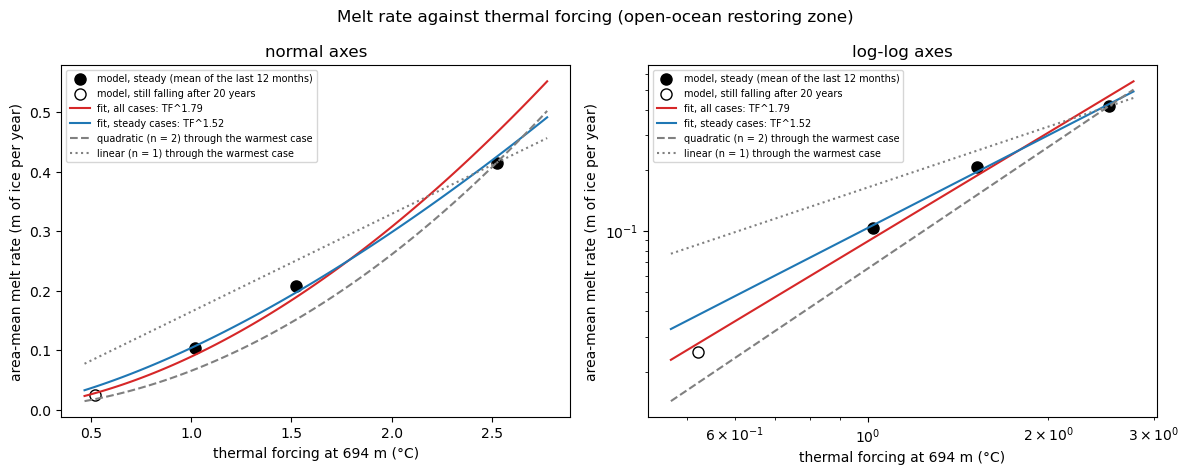

In [11]:
m = np.array([steady[c] for c in T_FAR])
is_steady = np.array([abs(change[c]) < STEADY_LIMIT for c in T_FAR])
fits = {}
for label, tf_dict in [("nominal", thermal_forcing), ("actual", tf_actual)]:
    tf = np.array([tf_dict[c] for c in T_FAR])
    n, log_a = np.polyfit(np.log(tf), np.log(m), 1)
    local = np.diff(np.log(m)) / np.diff(np.log(tf))
    fits[label] = (n, np.exp(log_a), tf)
    print(f"{label:8s} thermal forcing, all cases: melt = {np.exp(log_a):.4f} x TF^{n:.3f} | exponents between neighbours: {np.round(local, 2)}")
tf = fits["nominal"][2]
n_steady, log_a_steady = np.polyfit(np.log(tf[is_steady]), np.log(m[is_steady]), 1)
print(f"steady cases only ({', '.join(c for c, ok in zip(T_FAR, is_steady) if ok)}): melt = {np.exp(log_a_steady):.4f} x TF^{n_steady:.3f}")

n, a, tf = fits["nominal"]
tf_line = np.linspace(tf.min() * 0.9, tf.max() * 1.1, 100)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, logscale in zip(axes, [False, True]):
    ax.plot(tf[is_steady], m[is_steady], "o", ms=8, color="k", label="model, steady (mean of the last 12 months)")
    ax.plot(tf[~is_steady], m[~is_steady], "o", ms=8, mfc="none", color="k", label="model, still falling after 20 years")
    ax.plot(tf_line, a * tf_line ** n, color="tab:red", label=f"fit, all cases: TF^{n:.2f}")
    ax.plot(tf_line, np.exp(log_a_steady) * tf_line ** n_steady, color="tab:blue", label=f"fit, steady cases: TF^{n_steady:.2f}")
    ax.plot(tf_line, m[-1] * (tf_line / tf[-1]) ** 2, color="0.5", ls="--", label="quadratic (n = 2) through the warmest case")
    ax.plot(tf_line, m[-1] * (tf_line / tf[-1]), color="0.5", ls=":", label="linear (n = 1) through the warmest case")
    if logscale:
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_xlabel("thermal forcing at 694 m (°C)")
    ax.set_ylabel("area-mean melt rate (m of ice per year)")
    ax.set_title("log-log axes" if logscale else "normal axes")
    ax.legend(fontsize=7)
fig.suptitle("Melt rate against thermal forcing (open-ocean restoring zone)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_melt_vs_thermal_forcing.png"), dpi=150)
plt.show()

Why can the exponent be bigger than 1? With constant transfer coefficients, the local melt is roughly proportional to how warm the water next to the ice is. But more melt makes more fresh, buoyant meltwater, which drives a stronger circulation and pulls more warm water from the open ocean into the cavity. I measure that exchange as the total southward flow across the ice front (71°S), and also give the mean temperature of the water in the cavity and the strongest overturning in either direction under the ice.

In [12]:
lat_open = grid_open["yc"][:, 0]
j_front = np.argmin(np.abs(lat_open - ZONE_SOUTH))           # row of v-points on the ice front
cell_volume = grid_open["hfacc"] * grid_open["drf"][:, None, None] * grid_open["rac"][None, :, :]
cavity = (grid_open["yc"] < ZONE_SOUTH)[None, :, :] & (grid_open["hfacc"] > 0)
exchange = {}
cavity_t = {}
psi_cases = {}
for case in T_FAR:
    run = case_runs(case)[-1]
    last = output_iterations(run, "state_yearly")[-1]
    vvel = read_field(run, "state_yearly", "VVEL", last)
    theta = read_field(run, "state_yearly", "THETA", last)
    v_transport = vvel * grid_open["hfacs"] * grid_open["dxg"][None, :, :] * grid_open["drf"][:, None, None]   # m^3/s per cell face
    across = v_transport[:, j_front, :]
    exchange[case] = -np.sum(across[across < 0]) / 1e3                                      # southward flow into the cavity (mSv)
    cavity_t[case] = np.sum(theta * cell_volume * cavity) / np.sum(cell_volume * cavity)
    psi = np.cumsum(np.sum(v_transport, axis=2), axis=0) / 1e3                               # overturning (mSv)
    psi_cases[case] = psi
    under = lat_open < ZONE_SOUTH
    print(f"open_{case:4s}: TF {thermal_forcing[case]:.3f} °C | inflow across the ice front {exchange[case]:6.1f} mSv | "
          f"mean cavity temperature {cavity_t[case]:+.3f} °C (far field {T_FAR[case]:+.1f}) | overturning under the ice "
          f"from {psi[:, under].min():7.1f} to {psi[:, under].max():6.1f} mSv")
tf = fits["nominal"][2]
ex = np.array([exchange[c] for c in T_FAR])
print(f"inflow across the ice front grows like TF^{np.polyfit(np.log(tf), np.log(ex), 1)[0]:.2f}")

open_base: TF 0.521 °C | inflow across the ice front   11.0 mSv | mean cavity temperature -2.020 °C (far field -1.9) | overturning under the ice from    -0.0 to  103.0 mSv
open_p05 : TF 1.021 °C | inflow across the ice front   79.2 mSv | mean cavity temperature -1.853 °C (far field -1.4) | overturning under the ice from    -0.0 to  110.3 mSv
open_p10 : TF 1.521 °C | inflow across the ice front  115.8 mSv | mean cavity temperature -1.763 °C (far field -0.9) | overturning under the ice from   -77.1 to   68.5 mSv
open_p20 : TF 2.521 °C | inflow across the ice front  267.8 mSv | mean cavity temperature -1.491 °C (far field +0.1) | overturning under the ice from  -162.7 to   46.9 mSv
inflow across the ice front grows like TF^1.98


The overturning of the coldest and warmest cases. Positive values (red) mean northward flow above that depth and southward flow below it, as in step 2.

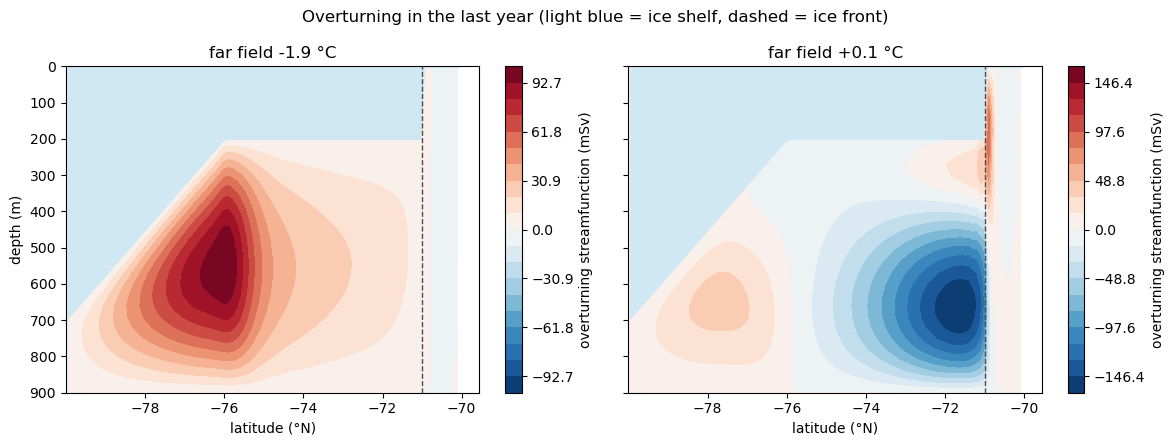

In [13]:
depth_faces = np.concatenate([[0.0], np.cumsum(grid_open["drf"])])
lat_v = grid_open["yc"][:, 0] - 0.05                   # v-points are on the southern edge of each cell
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, case in zip(axes, ["base", "p20"]):
    psi = np.vstack([np.zeros((1, NY)), psi_cases[case]])   # 0 at the top
    lim = np.abs(psi).max()
    mesh = ax.contourf(lat_v, depth_faces, psi, levels=np.linspace(-lim, lim, 21), cmap="RdBu_r")
    ax.fill_between(lat, 0, -np.fromfile(os.path.join(GEOMETRY_DIR, "icetopo_open_north.bin"), dtype=">f8").reshape(NY, NX)[:, 25],
                    color="#cfe8f3")
    ax.axvline(ZONE_SOUTH, color="0.3", ls="--", lw=1)
    fig.colorbar(mesh, ax=ax, label="overturning streamfunction (mSv)")
    ax.set_xlabel("latitude (°N)")
    ax.set_title(f"far field {T_FAR[case]:+.1f} °C")
axes[0].set_ylabel("depth (m)")
axes[0].set_ylim(900, 0)
fig.suptitle("Overturning in the last year (light blue = ice shelf, dashed = ice front)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_overturning_cases.png"), dpi=150)
plt.show()

Where does the extra melt happen? I split the ice into three regions: the single row of ice cells behind the ice front (where restored water meets the ice directly), all other ice, and the deep ice (draft deeper than 300 m, near the grounding line). I give each region's mean melt in the last 12 months, its share of the total (net) melt, and its own power-law exponent. The deep ice is part of 'rest of the ice'. A share can be above 100% because other places refreeze, which takes away from the net total.

In [14]:
front_row = iced & (grid_open["yc"] > ZONE_SOUTH - 0.1)          # the ice row just south of 71°S
regions = {"ice-front row": front_row, "rest of the ice": iced & ~front_row,
           "deep ice (draft < -300 m)": iced & (grid_open["ice_draft"] < -300.0)}
region_melt = {name: [] for name in regions}
for case in T_FAR:
    run = case_runs(case)[-1]
    its = output_iterations(run, "shelfice_monthly")[-12:]
    mm = np.zeros((NY, NX))
    for it in its:
        mm += melt_rate(read_field(run, "shelfice_monthly", "SHIfwFlx", it)) / len(its)
    total = np.sum(mm * grid_open["rac"] * iced)
    line = f"open_{case:4s}:"
    for name, region in regions.items():
        region_melt[name].append(area_mean(mm, grid_open, region))
        line += f" {name} {region_melt[name][-1]:.4f} m/yr ({100 * np.sum(mm * grid_open['rac'] * region) / total:.0f}% of total) |"
    print(line)
for name, region in regions.items():
    n_region = np.polyfit(np.log(fits["nominal"][2]), np.log(region_melt[name]), 1)[0]
    print(f"{name:26s}: {region.sum():4d} columns | exponent {n_region:+.2f}")

open_base: ice-front row 0.4936 m/yr (28% of total) | rest of the ice 0.0183 m/yr (72% of total) | deep ice (draft < -300 m) 0.1129 m/yr (126% of total) |
open_p05 : ice-front row 2.3135 m/yr (32% of total) | rest of the ice 0.0713 m/yr (68% of total) | deep ice (draft < -300 m) 0.1386 m/yr (37% of total) |
open_p10 : ice-front row 4.4077 m/yr (31% of total) | rest of the ice 0.1454 m/yr (69% of total) | deep ice (draft < -300 m) 0.1132 m/yr (15% of total) |
open_p20 : ice-front row 8.7979 m/yr (31% of total) | rest of the ice 0.2912 m/yr (69% of total) | deep ice (draft < -300 m) 0.1094 m/yr (7% of total) |
ice-front row             :   49 columns | exponent +1.83
rest of the ice           : 4312 columns | exponent +1.77
deep ice (draft < -300 m) : 1519 columns | exponent -0.04


The deep ice melts less when the far field is warmer. My explanation is density: the restored water has the same salinity (34.4 g/kg) as the starting water, so warming it makes it lighter. I compare the density of the deep water in the southern cavity (below 600 m, south of 76°S) with the density of the restored water, both at 700 dbar, using the model's equation of state (JMD95).

In [15]:
from MITgcmutils import density
deep_south = (grid_open["rc"][:, None, None] < -600.0) & (grid_open["yc"] < -76.0)[None, :, :] & (grid_open["hfacc"] > 0)
for case in T_FAR:
    run = case_runs(case)[-1]
    last = output_iterations(run, "state_yearly")[-1]
    theta = read_field(run, "state_yearly", "THETA", last)
    salt = read_field(run, "state_yearly", "SALT", last)
    t_deep = np.sum(theta * cell_volume * deep_south) / np.sum(cell_volume * deep_south)
    s_deep = np.sum(salt * cell_volume * deep_south) / np.sum(cell_volume * deep_south)
    rho_deep = float(density.jmd95(np.array(s_deep), np.array(t_deep), np.array(700.0)))
    rho_far = float(density.jmd95(np.array(S_FAR), np.array(T_FAR[case]), np.array(700.0)))
    print(f"open_{case:4s}: deep southern cavity {t_deep:+.3f} °C, {s_deep:.4f} g/kg, {rho_deep:.4f} kg/m^3 | "
          f"restored water {T_FAR[case]:+.1f} °C, {S_FAR} g/kg, {rho_far:.4f} kg/m^3 | "
          f"restored water is {'denser' if rho_far > rho_deep else 'lighter'} by {abs(rho_far - rho_deep):.4f} kg/m^3")

open_base: deep southern cavity -2.075 °C, 34.3427 g/kg, 1031.0096 kg/m^3 | restored water -1.9 °C, 34.4 g/kg, 1031.0477 kg/m^3 | restored water is denser by 0.0381 kg/m^3
open_p05 : deep southern cavity -2.024 °C, 34.3393 g/kg, 1031.0045 kg/m^3 | restored water -1.4 °C, 34.4 g/kg, 1031.0221 kg/m^3 | restored water is denser by 0.0175 kg/m^3
open_p10 : deep southern cavity -2.025 °C, 34.3501 g/kg, 1031.0133 kg/m^3 | restored water -0.9 °C, 34.4 g/kg, 1030.9931 kg/m^3 | restored water is lighter by 0.0202 kg/m^3
open_p20 : deep southern cavity -2.004 °C, 34.3415 g/kg, 1031.0054 kg/m^3 | restored water +0.1 °C, 34.4 g/kg, 1030.9252 kg/m^3 | restored water is lighter by 0.0802 kg/m^3


Finally, the melt maps of the coldest and warmest cases (mean of the last 12 months), each with its own colour scale.

open_base: largest melt 1.088 m/yr, strongest refreezing -0.662 m/yr, area refreezing 37.3%
open_p20: largest melt 14.614 m/yr, strongest refreezing -0.236 m/yr, area refreezing 6.0%


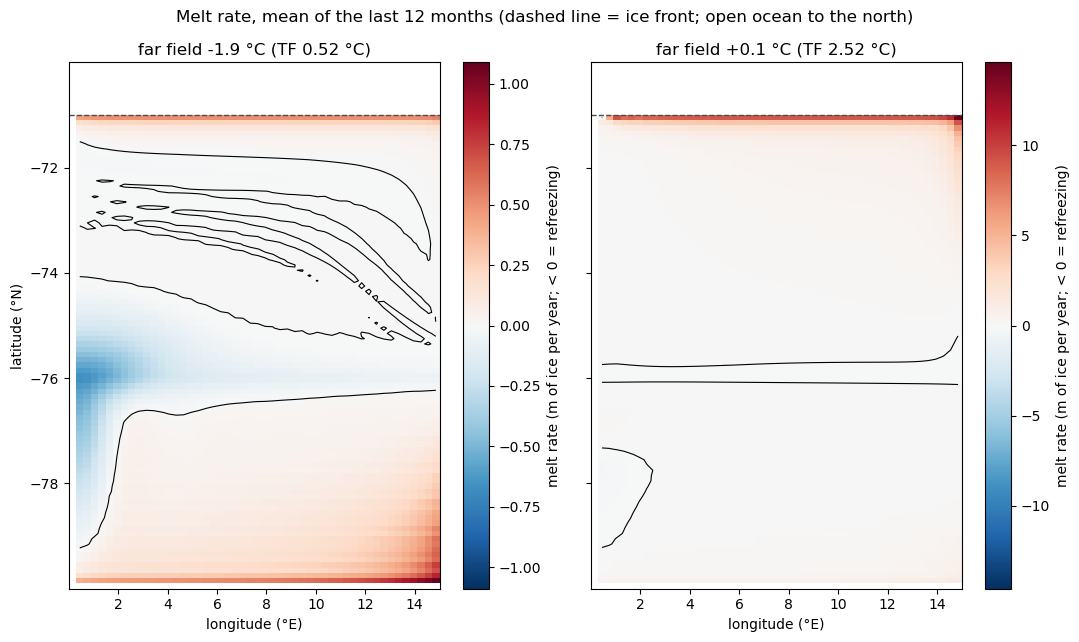

In [16]:
lon = grid_open["xc"][0, :]
lon_edges = np.concatenate([lon - 0.15, [lon[-1] + 0.15]])
fig, axes = plt.subplots(1, 2, figsize=(11, 6.5), sharey=True)
for ax, case in zip(axes, ["base", "p20"]):
    run = case_runs(case)[-1]
    its = output_iterations(run, "shelfice_monthly")[-12:]
    mm = np.zeros((NY, NX))
    for it in its:
        mm += melt_rate(read_field(run, "shelfice_monthly", "SHIfwFlx", it)) / len(its)
    mm = np.where(iced, mm, np.nan)
    lim = np.nanmax(np.abs(mm))
    mesh = ax.pcolormesh(lon_edges, lat_edges, mm, cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.contour(lon, lat, mm, levels=[0], colors="k", linewidths=0.8)
    ax.axhline(ZONE_SOUTH, color="0.3", ls="--", lw=1)
    fig.colorbar(mesh, ax=ax, label="melt rate (m of ice per year; < 0 = refreezing)")
    ax.set_xlabel("longitude (°E)")
    ax.set_title(f"far field {T_FAR[case]:+.1f} °C (TF {thermal_forcing[case]:.2f} °C)")
    print(f"open_{case}: largest melt {np.nanmax(mm):.3f} m/yr, strongest refreezing {np.nanmin(mm):.3f} m/yr, "
          f"area refreezing {100 * np.sum(grid_open['rac'] * iced * (mm < 0)) / np.sum(grid_open['rac'] * iced):.1f}%")
axes[0].set_ylabel("latitude (°N)")
fig.suptitle("Melt rate, mean of the last 12 months (dashed line = ice front; open ocean to the north)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_melt_maps.png"), dpi=150)
plt.show()